In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import timedelta

In [42]:
df = pd.read_parquet('/home/camarada/Documents/projects/temp-grss-nasa/data_/wunderground/Revision_temp_time.parquet')
df['time_max'] = pd.to_datetime(df['time_of_max_temp'], format= "%I:%M %p",errors='coerce').dt.time  
df['time_min'] = pd.to_datetime(df['time_of_min_temp'], format= "%I:%M %p",errors='coerce').dt.time 

## get date 
df['date_str'] = df['source_file'].apply(lambda x:x.strip().split('_',1)[1].replace('_','-'))
df['date']= pd.to_datetime(df['date_str'], format='%Y-%m-%d')
df['datetime_max']= pd.to_datetime(df['date_str'] + ' ' + df['time_of_max_temp'], format='%Y-%m-%d %I:%M %p')
df['datetime_min']= pd.to_datetime(df['date_str'] + ' ' + df['time_of_min_temp'], format='%Y-%m-%d %I:%M %p')

## diference between max min temperature 
df['diff_temp'] = df['max_temp'] - df['min_temp']

# difference of time between the min and the max 
## pass to time delta to calculate the diff
df['diff_time'] = df['time_max'].apply(lambda x: timedelta(hours=x.hour, minutes=x.minute)) - df['time_min'].apply(lambda x: timedelta(hours=x.hour, minutes=x.minute))

## add season column
df['season'] = df['date'].dt.month%12 // 3 + 1
df['season'] = df['season'].map({1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'})

In [52]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2202 entries, 0 to 2201
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   source_file       2202 non-null   object         
 1   max_temp          2202 non-null   float64        
 2   min_temp          2202 non-null   float64        
 3   time_of_max_temp  2202 non-null   object         
 4   time_of_min_temp  2202 non-null   object         
 5   time_max          2202 non-null   object         
 6   time_min          2202 non-null   object         
 7   date_str          2202 non-null   object         
 8   date              2202 non-null   datetime64[ns] 
 9   datetime_max      2202 non-null   datetime64[ns] 
 10  datetime_min      2202 non-null   datetime64[ns] 
 11  diff_temp         2202 non-null   float64        
 12  diff_time         2202 non-null   timedelta64[ns]
 13  season            2202 non-null   object         
dtypes: datet

<Axes: ylabel='Frequency'>

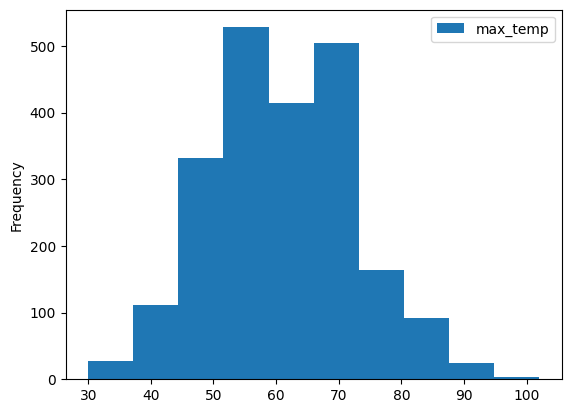

In [ ]:
df.set_index('datetime_max')[['max_temp']].plot(kind='hist')


<Axes: ylabel='Frequency'>

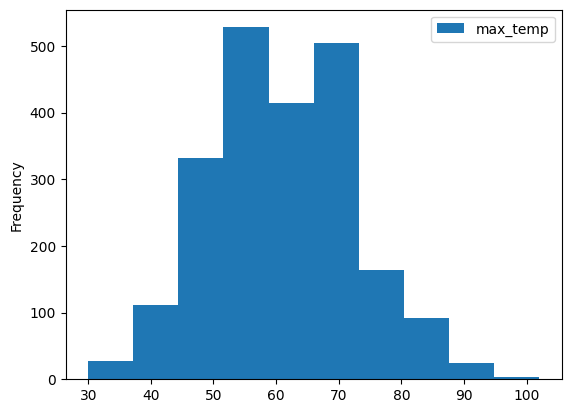

In [37]:
df.set_index('time_max')[['max_temp']].plot(kind='hist')


In [55]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Category10

output_notebook()

df = df.sort_values("date")

## convert to celsius
df['max_temp'] = (df['max_temp'] - 32) * 5.0/9.0
df['min_temp'] = (df['min_temp'] - 32) * 5.0/9.0
source = ColumnDataSource(df)

p = figure(
    x_axis_type="datetime",
    width=900,
    height=400,
    title="Daily Max and Min Temperature",
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

p.line('date', 'max_temp', source=source,
       color=Category10[3][0], legend_label="Max Temp", line_width=2)

p.line('date', 'min_temp', source=source,
       color=Category10[3][1], legend_label="Min Temp", line_width=2)

hover = HoverTool(
    tooltips=[
        ("Date", "@date{%F}"),
        ("Max Temp", "@max_temp"),
        ("Min Temp", "@min_temp")
    ],
    formatters={'@date': 'datetime'},
    mode='vline'
)

p.add_tools(hover)

p.legend.click_policy = "hide"
p.xaxis.axis_label = "Date"
p.yaxis.axis_label = "Temperature"

show(p)

Loading BokehJS ...

In [14]:
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed